In [30]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from scipy.ndimage import gaussian_filter


import cmath

from qutip import *
from joblib import Parallel, delayed

from numba import njit, prange
from numba import set_num_threads, get_num_threads

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.ndimage import gaussian_filter


# --- Labels ---
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}

In [31]:

def kernel(vx, vt, d):
    l_cut = 2.  #in nm
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mK = np.log( np.abs( (np.sqrt( (d**2 - mx**2.)*(d**2.-mt**2) ) + d**2 - mx*mt )/(2*d**2) ) ) - np.log( np.abs((mx-mt + 1e-12)/(2*d)) )*(1-np.exp(-np.abs(mx-mt)/l_cut ))    
    
    return mK - np.amin(mK)*0

def kernel_1D_image(vx, vt, d, dedge):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mdedge = dedge * np.ones(shape=(len(vx), len(vt)))
    l_cut = 2.  #in nm
        
    #mK = np.log( np.abs( (np.sqrt( (md**2 - mx**2.)*(md**2.-mt**2) ) + d**2 - mx*mt )/(mx-mt + 1e-7)/md ) ) 
    #mK += np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-7 ) )
    
    #mK = - ( np.log( np.abs( mx - mt + 1e-7 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) - np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-7 ) )  ) 
    #mK = - ( np.log( np.abs( mx - mt + 1e-10 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) - np.log( np.sqrt( (mx - mt)**2 + (2*mdedge)**2 + 1e-10 ) )  ) 
    mK = - np.log( np.abs( mx - mt + 1e-12 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) + np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-12 ) ) + 0*np.log( np.sqrt( (mx - mt)**2 + (2*3400)**2 + 1e-10 ) )   
    
    return mK - np.amin(mK)

def kernel_1D_0(vx, vt, d):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    l_cut = 1  #in nm
    mK = - np.log( np.abs( mx - mt + 1e-12 )/(d) )*(1-np.exp(-np.abs(mx-mt)/l_cut ))    
    
    return mK - np.amin(mK)

def kernel_3D(vx, vt, d, sides, dedge):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    mK = np.zeros(shape=(len(vx), len(vt)))
    
    l_cut = .1  #in nm
    if sides == 2:
        for m in range(-100,100):
            mK += (1./np.abs( mx - mt - 4*d*m + 1e-7 ) - 1./np.abs( mx + mt + 2*d - 4*d*m + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
    elif sides == 1:
        #m = 1
        #mK = (1./np.abs( mx - mt + 1e-7 ) - 1./np.abs( mx + mt + 2*d - 4*d*m + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
        
        #mK = (1./np.abs( mx - mt + 1e-7 ) - 1./np.abs( mx + mt + 2*d + 2*dedge + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm   LEFT
        mK = (1./np.abs( mx - mt + 1e-7 )* (1-np.exp(-np.abs(mx-mt)/l_cut )) - 1./np.abs( mx + mt - 2*d - 2*dedge + 1e-7 ) )   #smooth UV cutoff at l_cut in nm      RIGHT
    elif sides == 0:
        m = 1
        mK = (1./np.abs( mx - mt + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
    return mK - np.amin(mK)

def int_donor_U(vx, d, mK, n0, U0):
    vDonors = np.zeros(len(vx))
    dx = np.abs(vx[0]-vx[1])
    vDonors = - np.sum(mK, axis=1)*dx *n0*U0
    return vDonors

def int_nonhomo_donor_U(vx, d, mK, n0, U0):
    vDonors = np.zeros(len(vx))
    dx = np.abs(vx[0]-vx[1])
    vDonors = - np.dot(mK, n0)*dx *U0
    return vDonors

def dos_B( B, vE, gam0 ):
    lB = 25/B**.5   #in nm and B in T
    omB = 1.76 * B  #in meV and B in T
    EZ = omB/3.
    Gam = gam0 * omB * (10/B)**.5
    vD = np.zeros( len(vE) )
    for n in range(150):
        epsn = (.5+n)*omB
        vD += 1./(2*np.pi*lB**2.) * ( np.exp( - (epsn - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 + np.exp( - (epsn+EZ - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 )
    
    return vD

@njit
def number_e(T, vx, vU, vD, vE, mu):    #T in meV
    num_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    
    for ne, E in enumerate(vE):
        F = 1./( np.exp( (E + vU - mu)/T ) + 1. )
        num_e += dE*vD[ne] * F
    
    return num_e

def ffddddmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    zpE = .5*omB*0
    if T > .01:
        for ne, E1 in enumerate(vE):
            E = E1 - zpE
            #dF = np.exp( (E + vU - mu)/T ) /( np.exp( (E + vU - mu)/T ) + 1. )**2./T 
            logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.
            dF = np.exp(logdFT)/T
            dnum_e += dE*vD[ne] * dF
    else:
        for nx, x in enumerate(vx):
            ne = np.argmin(np.abs(vE- zpE - (mu - vU[nx] ) ))
            dnum_e[nx] = vD[ne]
    
    return dnum_e

In [32]:
def load_Ux(filename):
    # ---- Read numerical columns ----
    data = np.loadtxt(filename)

    vx     = data[:, 0]
    vU     = data[:, 1]
    vnum_e = data[:, 2]
    dnum_e = data[:, 3]

    # ---- Read metadata from header ----
    mu  = None
    omB = None

    with open(filename, "r") as f:
        for line in f:
            if "mu =" in line:
                mu = float(line.split("=")[1])
            if "omB =" in line:
                omB = float(line.split("=")[1])

    return vx, vU, vnum_e, dnum_e, mu, omB

vx, vU, vnum_e, dnum_e, mu, omB = load_Ux("Ux.dat")

T = .05 #in meV 0.01 => 0.116 K
gam0 = 0.03  #adimensional width of the LLs
B = omB/1.76
lB = 25/B**.5   #in nm


d = 2000   #in nm


vt = vx.copy()
mK = kernel(vx, vt, d)

vE = np.linspace(.0001, 6, 1000) * omB
vD = dos_B( B, vE, gam0 )

targ_num_e = 5. * 1e-3     #in nm^-2 ---> 10^-3 nm^-2 = 10^11 cm^-2
num_D = targ_num_e * 1.8

kappa0 = 1.44/13. * 10e3  #in meV * nm


dx = np.abs(vx[1]-vx[0])
vUD_int = int_nonhomo_donor_U(vx, d, mK, num_D*np.ones(len(vx)), kappa0)



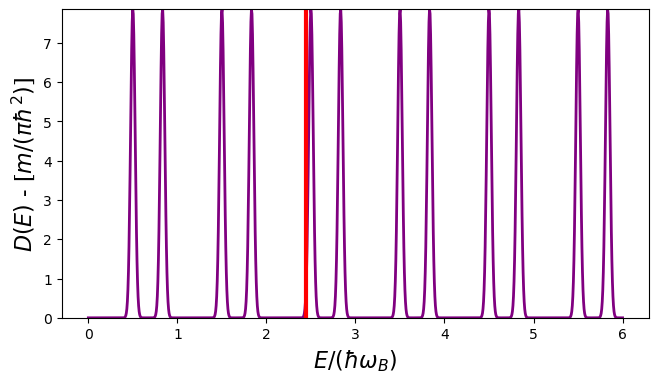

In [33]:
plt.plot(vE/omB, np.pi*lB**2*omB*vD, color='purple', linewidth=2)
plt.vlines(mu/omB, ymin=0, ymax=np.amax(np.pi*lB**2*omB*vD), color='red', linewidth=3)
plt.ylim(0,np.pi*lB**2*omB*np.amax(vD))

plt.xlabel(r"$E/(\hbar\omega_B)$", fontdict=font)
plt.ylabel(r"$D(E)$ - [$m/(\pi \hbar^2)$]", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()

In [34]:
dnum_e = ffddddmu_dnumber_e(T, vx, vU, vD, vE, mu)

mKcomp = mK
matrix_inv = np.eye(len(vx)) -  kappa0 * dx * np.multiply(mKcomp , dnum_e[np.newaxis, :])
MMmatrix = scipy.linalg.inv(matrix_inv)

/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_83190/2264450253.py:99: RuntimeWarning: overflow encountered in exp
  logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.


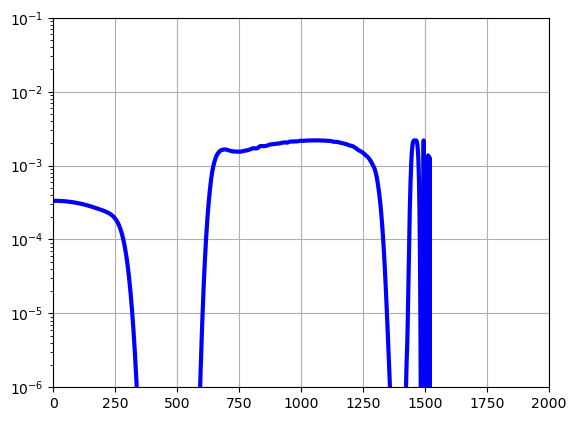

In [35]:
plt.plot( vx, dnum_e, color='blue', linewidth=3 )

plt.yscale('log')
plt.ylim(1e-6,1e-1)
plt.xlim(0,d)


plt.grid()

'\nax = plt.gca()\n# --- inset: right side, vertically centered ---\naxins = inset_axes(\n    ax,\n    width="35%", height="45%",              # size of inset (tweak as you like)\n    loc="center left",                     # right side, centered vertically\n    borderpad=1.2\n)\n\n# plot ONLY the red curve in the inset (or add the blue too if you want)\naxins.plot(vx, (smoothU)/omB, color="red", linewidth=2)\naxins.plot(vx, (vU)/omB, color="green", linewidth=2, linestyle=\'--\')\n\n\n# zoom limits\naxins.set_xlim(3000, 4000)\naxins.set_ylim(0., 1.2)\n\n# optional: make inset cleaner\naxins.grid(True, alpha=0.4)\naxins.tick_params(labelsize=10)\n\n# optional: draw a box on the main plot showing the zoomed region + connectors\n#mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4")\n'

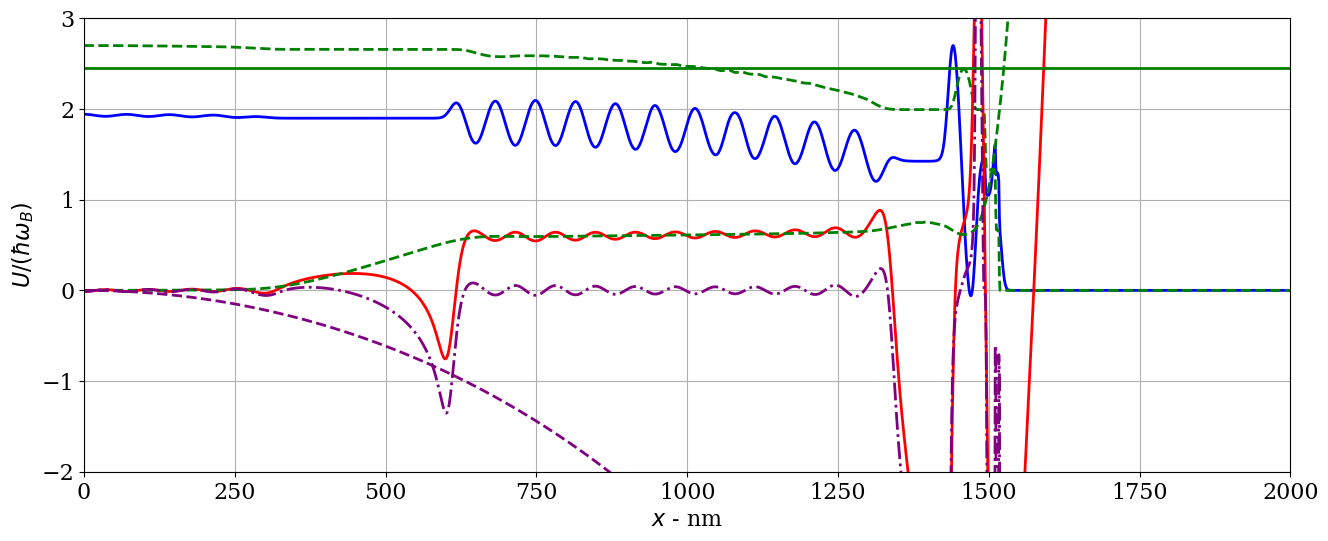

In [37]:
ymax = 3



ne_1s = 1./(lB) * 1e-0  #1D electron density ( multiplied by scaling factor lB/L_distance )
#dmetal = 200
#Uimg_cond = -kappa0/2./np.abs(vx-d-dmetal) * 100 #/(1.+100*dnum_e)
Uimg_cond = kappa0*np.log( np.abs( (np.sqrt( (d**2 - vx**2.)*(d**2.-vx**2) ) + d**2 - vx*vx )/(2*d**2) ) ) * ne_1s
Uimg_cond = Uimg_cond - np.amax(Uimg_cond)

Uimg_screen = np.matmul(MMmatrix, Uimg_cond)

smoothing = 5
smoothUimg_screen = gaussian_filter(Uimg_screen, sigma=smoothing)
delta_N = dnum_e * Uimg_screen

smoothN = gaussian_filter(delta_N, sigma=smoothing)

smoothU = gaussian_filter(vU+Uimg_screen, sigma=smoothing)
#smoothU = vU*0+Uimg_screen


plt.plot( vx, (vnum_e-smoothN)/np.amax(vnum_e-smoothN)*ymax*9./10., color='blue', linewidth=2 )
plt.plot( vx, (vnum_e)/np.amax(vnum_e)*ymax*9./10., color='green', linestyle='--', linewidth=2 )

#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
#plt.plot(vx, (vU+dU)/omB , color='red', linewidth=2)
plt.plot(vx, (smoothU)/omB , color='red', linewidth=2)
plt.plot(vx, (vU)/omB , color='green', linewidth=2, linestyle='--')

plt.plot(vx, (Uimg_cond)/omB , color='purple', linewidth=2, linestyle='--')
plt.plot(vx, (Uimg_screen)/omB , color='purple', linewidth=2, linestyle='-.')






plt.hlines(mu/omB, xmin=-d, xmax=d, color='green', linewidth=2)
#plt.plot(vx, vUD/omB, linestyle='--')
plt.ylim(-2.,ymax)
plt.xlim(0,2000)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - nm", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()

plt.gcf().set_size_inches(340 / 25.4, 140 / 25.4)
plt.tight_layout()


"""
ax = plt.gca()
# --- inset: right side, vertically centered ---
axins = inset_axes(
    ax,
    width="35%", height="45%",              # size of inset (tweak as you like)
    loc="center left",                     # right side, centered vertically
    borderpad=1.2
)

# plot ONLY the red curve in the inset (or add the blue too if you want)
axins.plot(vx, (smoothU)/omB, color="red", linewidth=2)
axins.plot(vx, (vU)/omB, color="green", linewidth=2, linestyle='--')


# zoom limits
axins.set_xlim(3000, 4000)
axins.set_ylim(0., 1.2)

# optional: make inset cleaner
axins.grid(True, alpha=0.4)
axins.tick_params(labelsize=10)

# optional: draw a box on the main plot showing the zoomed region + connectors
#mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4")
"""